In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [12]:
# Load one month to start - let's use a recent one
df = pd.read_csv('data/CRMLSSold202605.csv', low_memory=False)

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())


Shape: (23260, 78)

Columns: ['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChang

In [13]:
print('PropertyType value counts:')
print(df['PropertyType'].value_counts())

print('\nPropertySubType value counts:')
print(df['PropertySubType'].value_counts())


PropertyType value counts:
PropertyType
Residential            15803
ResidentialLease        5342
Land                     660
ResidentialIncome        633
ManufacturedInPark       591
CommercialSale           127
CommercialLease           98
BusinessOpportunity        6
Name: count, dtype: int64

PropertySubType value counts:
PropertySubType
SingleFamilyResidence    14404
Condominium               3895
Townhouse                 1383
Apartment                  611
Duplex                     474
ManufacturedOnLand         226
Triplex                    153
Quadruplex                 153
MixedUse                    83
StockCooperative            61
Office                      56
Retail                      28
Industrial                  19
Studio                      17
Business                    16
RoomingHouse                16
Cabin                       15
Warehouse                   13
BoatSlip                    11
WaterPositionWithLand        5
MobileHome                   4
Mult

In [9]:
df_filtered = df[(df['PropertyType'] == 'Residential') & (df['PropertySubType'] == 'SingleFamilyResidence')]

print('Filtered shape:', df_filtered.shape)
print('\nMissing values in key columns:')
print(df_filtered[['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']].isnull().sum())

Filtered shape: (12024, 78)

Missing values in key columns:
ClosePrice                 0
LivingArea                 7
BedroomsTotal              0
BathroomsTotalInteger      0
LotSizeSquareFeet        204
dtype: int64


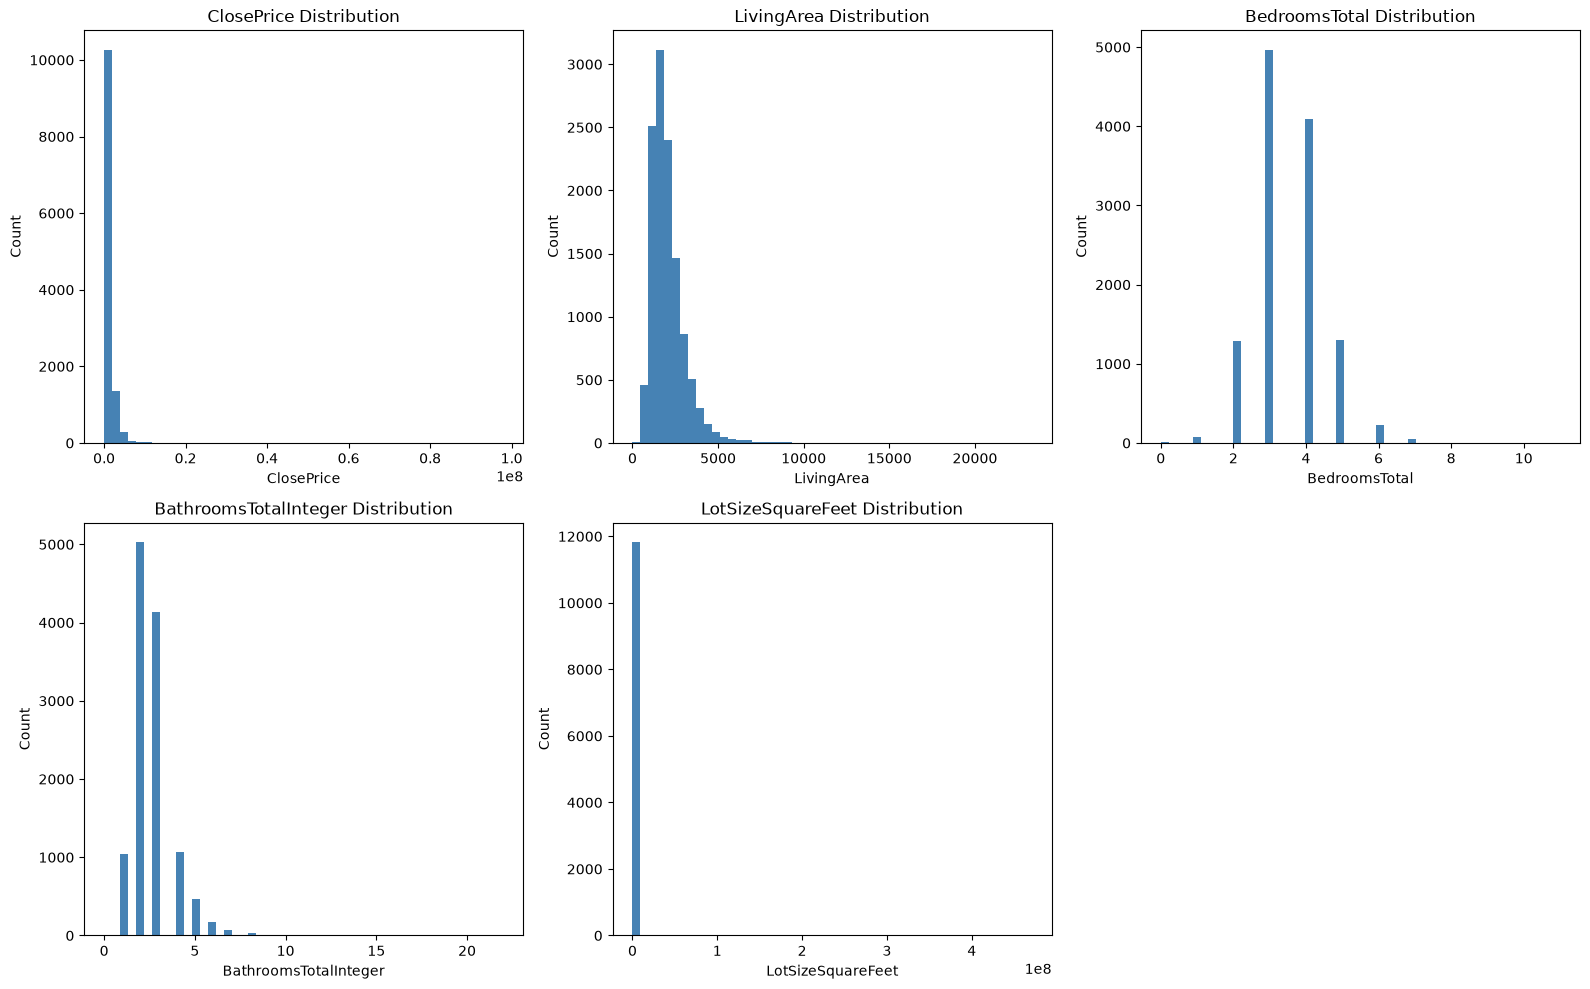

In [10]:
# import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']

for i, col in enumerate(features):
    axes[i].hist(df_filtered[col].dropna(), bins=50, color='steelblue', edgecolor='none')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
print('Top 5 ClosePrice values:')
print(df_filtered['ClosePrice'].nlargest(5))

print('\nTop 5 LotSizeSquareFeet values:')
print(df_filtered['LotSizeSquareFeet'].nlargest(5))

Top 5 ClosePrice values:
19231    97972500.0
15235    48720000.0
76       35000000.0
4311     31000000.0
1243     28000000.0
Name: ClosePrice, dtype: float64

Top 5 LotSizeSquareFeet values:
11171    470665800.0
9798     326700000.0
13273     12290018.4
19769     10454400.0
420        6969600.0
Name: LotSizeSquareFeet, dtype: float64


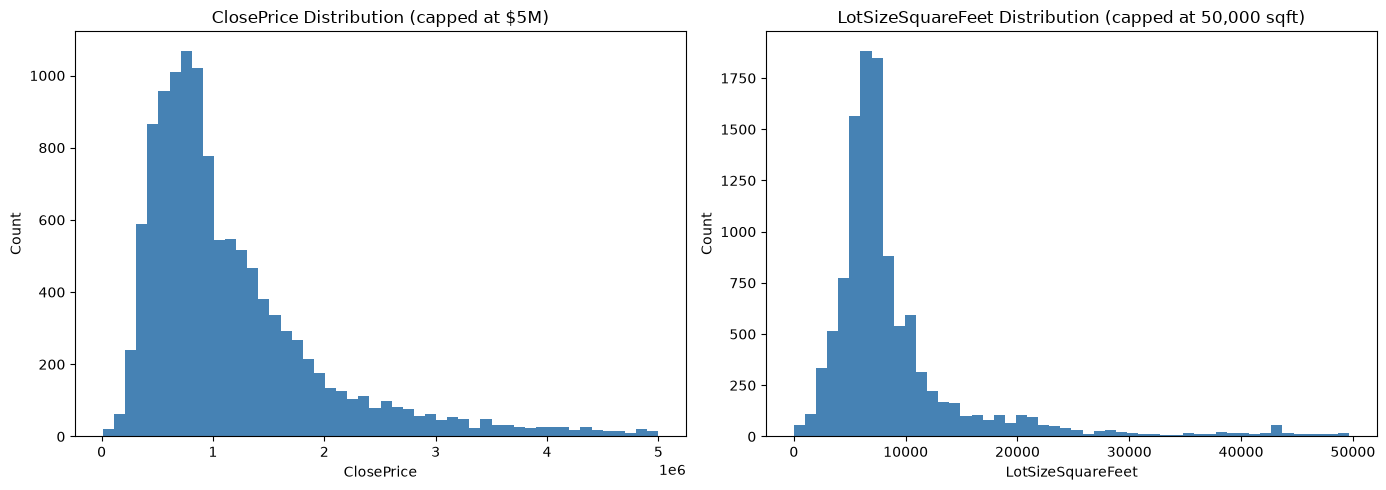

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cap ClosePrice at $5M for viewing
price_capped = df_filtered[df_filtered['ClosePrice'] < 5000000]['ClosePrice']
axes[0].hist(price_capped, bins=50, color='steelblue', edgecolor='none')
axes[0].set_title('ClosePrice Distribution (capped at $5M)')
axes[0].set_xlabel('ClosePrice')
axes[0].set_ylabel('Count')

# Cap LotSize at 50,000 sqft for viewing
lot_capped = df_filtered[df_filtered['LotSizeSquareFeet'] < 50000]['LotSizeSquareFeet']
axes[1].hist(lot_capped, bins=50, color='steelblue', edgecolor='none')
axes[1].set_title('LotSizeSquareFeet Distribution (capped at 50,000 sqft)')
axes[1].set_xlabel('LotSizeSquareFeet')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [17]:
# import glob

# Get all CSV files except the flagged _filled one
all_files = glob.glob('data/CRMLSSold*.csv')
all_files = [f for f in all_files if '_filled' not in f]

print(f'Found {len(all_files)} files to load:')
for f in sorted(all_files):
    print(' ', f)

Found 21 files to load:
  data/CRMLSSold202408.csv
  data/CRMLSSold202409.csv
  data/CRMLSSold202410.csv
  data/CRMLSSold202411.csv
  data/CRMLSSold202412.csv
  data/CRMLSSold202502.csv
  data/CRMLSSold202503.csv
  data/CRMLSSold202504.csv
  data/CRMLSSold202505.csv
  data/CRMLSSold202506.csv
  data/CRMLSSold202507.csv
  data/CRMLSSold202508.csv
  data/CRMLSSold202509.csv
  data/CRMLSSold202510.csv
  data/CRMLSSold202511.csv
  data/CRMLSSold202512.csv
  data/CRMLSSold202601.csv
  data/CRMLSSold202602.csv
  data/CRMLSSold202603.csv
  data/CRMLSSold202604.csv
  data/CRMLSSold202605.csv


In [18]:
dfs = []

for file in sorted(all_files):
    temp_df = pd.read_csv(file, low_memory=False)
    temp_filtered = temp_df[(temp_df['PropertyType'] == 'Residential') & 
                              (temp_df['PropertySubType'] == 'SingleFamilyResidence')]
    dfs.append(temp_filtered)
    print(f'{file}: {temp_df.shape[0]} total rows -> {temp_filtered.shape[0]} after filter')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nCombined shape: {df_all.shape}')


data/CRMLSSold202408.csv: 24558 total rows -> 12433 after filter
data/CRMLSSold202409.csv: 21267 total rows -> 10909 after filter
data/CRMLSSold202410.csv: 23274 total rows -> 12347 after filter
data/CRMLSSold202411.csv: 20279 total rows -> 10692 after filter
data/CRMLSSold202412.csv: 20241 total rows -> 10624 after filter
data/CRMLSSold202502.csv: 18702 total rows -> 8851 after filter
data/CRMLSSold202503.csv: 21445 total rows -> 10610 after filter
data/CRMLSSold202504.csv: 23262 total rows -> 11880 after filter
data/CRMLSSold202505.csv: 23154 total rows -> 11777 after filter
data/CRMLSSold202506.csv: 22883 total rows -> 11701 after filter
data/CRMLSSold202507.csv: 23646 total rows -> 12114 after filter
data/CRMLSSold202508.csv: 22972 total rows -> 11454 after filter
data/CRMLSSold202509.csv: 22443 total rows -> 11456 after filter
data/CRMLSSold202510.csv: 23233 total rows -> 12029 after filter
data/CRMLSSold202511.csv: 19088 total rows -> 9739 after filter
data/CRMLSSold202512.csv: 2

In [19]:
key_cols = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt']

print('Missing values in combined dataset:')
print(df_all[key_cols].isnull().sum())

print('\nMissing as % of total:')
print((df_all[key_cols].isnull().sum() / len(df_all) * 100).round(2))

Missing values in combined dataset:
ClosePrice                  1
LivingArea                119
BedroomsTotal               0
BathroomsTotalInteger      27
LotSizeSquareFeet        3950
YearBuilt                 164
dtype: int64

Missing as % of total:
ClosePrice               0.00
LivingArea               0.05
BedroomsTotal            0.00
BathroomsTotalInteger    0.01
LotSizeSquareFeet        1.71
YearBuilt                0.07
dtype: float64


In [20]:
df_all[df_all['ClosePrice'].isnull()][['ListingId', 'CloseDate', 'City', 'ClosePrice', 'MlsStatus']]

,ListingId,CloseDate,City,ClosePrice,MlsStatus
54142,MC24191255,2024-12-13,Tracy,NaN,Closed
